# Bivariate Exploratory Data Analysis — London Airbnb

**Owner:** Sanjana Phalke  
**Input:** `data/listings_clean.csv` from Varuna's updated `01_cleaning.ipynb`  
**Handoff:** Ngoc's updated univariate analysis

### Goal
Identify which **listing and host features are associated with a top rating (4.8+)** and prepare defensible candidate features for the classification model.

This revision follows the univariate handoff: **price, room type, accommodates, borough, host type, host tenure, amenity count, and minimum nights**. It also adds
- the three bivariate pair types taught in Lecture 5,
- statistical tests and effect sizes next to charts,
- 80% and 95% confidence intervals for rate comparisons,
- sample sizes before comparison,
- a numeric × numeric redundancy check,
- a final decision table and ML handoff,
- a CPU timing section for later CPU vs RAPIDS benchmarking.

`host_identity_verified` is not carried forward because the univariate analysis found it is near-universal and therefore low-information. Review sub-scores and `host_is_superhost` remain excluded from model features because of leakage.

In [1]:
import json
import os
import time
import platform
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, norm
from IPython.display import Markdown, display

# Consistent project styling
BLUE = "#2E86AB"
ORANGE = "#F18F01"
GREEN = "#2A9D8F"
PURPLE = "#8E6CBE"
CORAL = "#E76F51"
GREY = "#6C757D"

df = pd.read_csv("../data/listings_clean.csv", low_memory=False)

expected_rows, expected_cols = 92635, 80
print("Loaded cleaned dataset:", df.shape)
if df.shape != (expected_rows, expected_cols):
    print(f"WARNING: latest cleaning output is expected to be ({expected_rows}, {expected_cols}).")
    print("Re-run the updated 01_cleaning.ipynb before final submission.")

required = [
    "top_rated", "review_scores_rating", "price_capped", "price_capped_imp",
    "price_capped_missing", "room_type", "accommodates", "neighbourhood_cleansed",
    "calculated_host_listings_count", "hosts_time_as_host_years",
    "amenities", "minimum_nights_capped"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns from latest cleaning output: {missing}")

rated = df[df["top_rated"].notna()].copy()
rated["top_rated"] = rated["top_rated"].astype(int)
rated["Rating Group"] = rated["top_rated"].map({0: "Not Top-Rated", 1: "Top-Rated"})
rated["log_price"] = np.log1p(rated["price_capped"])
rated["host_type"] = np.where(
    rated["calculated_host_listings_count"].eq(1),
    "Single-listing host",
    "Multi-listing host"
)
rated["amenity_count"] = rated["amenities"].apply(
    lambda s: len(json.loads(s)) if isinstance(s, str) else 0
)

print("Rated listings used for target-based bivariate analysis:", rated.shape[0])
print((rated["top_rated"].value_counts(normalize=True).sort_index() * 100).round(2))

Loaded cleaned dataset: (92635, 80)
Rated listings used for target-based bivariate analysis: 70708
top_rated
0    43.95
1    56.05
Name: proportion, dtype: float64


## Statistical Helpers

For rate comparisons, the **thick interval represents the 80% Wilson confidence interval**, while the **thin interval represents the 95% Wilson confidence interval**, providing a visual measure of uncertainty.

Because the dataset is large, very small p-values may occur even when relationships are weak. Therefore, statistical tests are interpreted alongside appropriate **effect sizes**:

- **Cramér's V** for categorical or grouped comparisons,
- **rank-biserial correlation** for the skewed price comparison,
- **Spearman's ρ** for numeric × numeric relationships.

Statistical significance, effect size, confidence intervals, and sample size are considered together when determining the practical importance of each relationship.

In [2]:
def clean_axes(ax):
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    ax.grid(axis="x", alpha=0.18)


def wilson_interval(successes, n, confidence):
    z = norm.ppf(1 - (1 - confidence) / 2)
    p = successes / n
    den = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return center - half, center + half


def rate_summary(data, group_col, order=None):
    out = (
        data.groupby(group_col, observed=False)["top_rated"]
        .agg(rated_listings="count", top_rated_listings="sum", top_rated_rate="mean")
        .reset_index()
    )
    for conf, tag in [(0.80, "80"), (0.95, "95")]:
        lo, hi = wilson_interval(
            out["top_rated_listings"].astype(float),
            out["rated_listings"].astype(float),
            conf
        )
        out[f"ci{tag}_low"] = lo
        out[f"ci{tag}_high"] = hi

    if order is not None:
        out[group_col] = pd.Categorical(out[group_col], categories=order, ordered=True)
        out = out.sort_values(group_col)
    return out


def chi_square_effect(data, group_col):
    table = pd.crosstab(data[group_col], data["top_rated"])
    chi2, p, dof, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    v = np.sqrt(chi2 / (n * min(table.shape[0] - 1, table.shape[1] - 1)))
    return chi2, p, dof, v


def p_text(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


def plot_rate_barh(summary, category_col, title, filename, stat_text,
                   overall=None, figsize=(10, 5.5), xlim=(0, 82), label_font=8):
    s = summary.copy()
    y = np.arange(len(s))
    rates = s["top_rated_rate"].to_numpy() * 100

    plt.figure(figsize=figsize)
    palette = sns.color_palette("Set2", len(s))
    bars = plt.barh(y, rates, color=palette, edgecolor="0.25", linewidth=0.7)

    # Redundant encoding for grayscale printing
    hatches = ["//", "\\\\", "..", "xx", "++", "oo", "--", "**"]
    for i, bar in enumerate(bars):
        bar.set_hatch(hatches[i % len(hatches)])

    # 95% CI = thin; 80% CI = thick
    low95 = s["ci95_low"].to_numpy() * 100
    high95 = s["ci95_high"].to_numpy() * 100
    low80 = s["ci80_low"].to_numpy() * 100
    high80 = s["ci80_high"].to_numpy() * 100

    plt.errorbar(
        rates, y,
        xerr=[rates - low95, high95 - rates],
        fmt="none", ecolor="black", elinewidth=1.0, capsize=3, zorder=4
    )
    plt.errorbar(
        rates, y,
        xerr=[rates - low80, high80 - rates],
        fmt="none", ecolor="black", elinewidth=3.0, capsize=0, zorder=5
    )

    labels = s[category_col].astype(str).tolist()
    plt.yticks(y, labels)
    plt.xlabel("Top-Rated Listings (%)")
    plt.ylabel("")
    plt.xlim(*xlim)
    plt.title(title, loc="left", fontsize=13, weight="bold", pad=18)

    ax = plt.gca()
    ax.invert_yaxis()  # first category in the table appears at the top

    if overall is not None:
        plt.axvline(overall * 100, color=GREY, linestyle="--", linewidth=1.3)
        ax.text(
            overall * 100 + 0.4, 1.005,
            f"Overall: {overall * 100:.1f}%",
            transform=ax.get_xaxis_transform(),
            fontsize=8, color=GREY, va="bottom", ha="left"
        )

    # Place labels just beyond the 95% CI so they do not collide with the error bars
    for yi, (rate, hi, n) in enumerate(zip(rates, high95, s["rated_listings"])):
        ax.text(hi + 0.8, yi, f"{rate:.1f}%  (n={n:,})",
                va="center", fontsize=label_font)

    clean_axes(ax)
    ax.text(
        0.99, 0.02,
        stat_text + "\nThick = 80% CI; thin = 95% CI",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=7.5, color="0.25",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.80", alpha=0.90)
    )

    plt.tight_layout()
    plt.savefig(filename, dpi=500, bbox_inches="tight")
    plt.show()

overall_rate = rated["top_rated"].mean()
print(f"Overall top-rated rate: {overall_rate * 100:.2f}%")

Overall top-rated rate: 56.05%


## 1. Price vs Top-Rated Status - numeric × categorical

**Question:** Are top-rated listings priced differently from non-top-rated listings?

The univariate analysis found strong right-skew in price, so this comparison uses `price_capped` from cleaning and a **logarithmic x-axis**. Missing prices are not invented for this descriptive chart; only observed prices are shown.

,count,mean,median,std
Rating Group,,,,
Not Top-Rated,22520,219.53,172.50,185.08
Top-Rated,26150,246.16,184.67,219.16


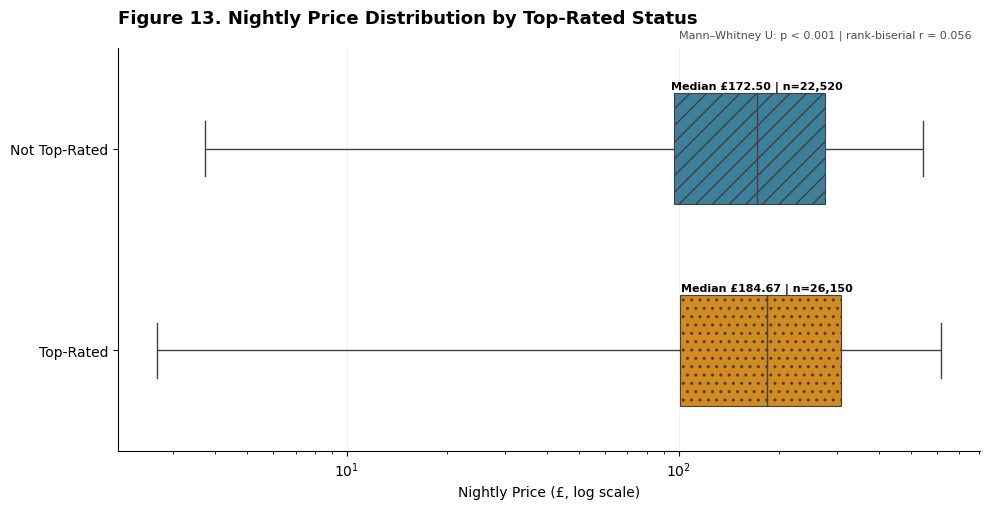

In [3]:
price_data = rated.dropna(subset=["price_capped"]).copy()
price_order = ["Not Top-Rated", "Top-Rated"]

# Summary statistics
price_summary = (
    price_data.groupby("Rating Group", observed=False)["price_capped"]
    .agg(["count", "mean", "median", "std"])
    .reindex(price_order)
)
display(price_summary.round(2))

# Mann–Whitney U test + rank-biserial effect size
top = price_data.loc[price_data["top_rated"].eq(1), "price_capped"]
not_top = price_data.loc[price_data["top_rated"].eq(0), "price_capped"]

u_stat, price_p = mannwhitneyu(top, not_top, alternative="two-sided")
rank_biserial = 2 * u_stat / (len(top) * len(not_top)) - 1

# Plot
plt.figure(figsize=(10, 5.2))

ax = sns.boxplot(
    data=price_data,
    x="price_capped",
    y="Rating Group",
    order=price_order,
    showfliers=False,
    width=0.55,
    palette=[BLUE, ORANGE],
    hue="Rating Group",
    legend=False
)

# Redundant encoding for grayscale printing
hatches = ["//", ".."]
for patch, hatch in zip(ax.patches, hatches):
    patch.set_hatch(hatch)
    patch.set_edgecolor("0.25")
    patch.set_linewidth(0.8)

# Log scale because price is strongly right-skewed
ax.set_xscale("log")

ax.set_xlabel("Nightly Price (£, log scale)")
ax.set_ylabel("")
ax.set_title(
    "Figure 13. Nightly Price Distribution by Top-Rated Status",
    loc="left",
    fontsize=13,
    weight="bold",
    pad=18
)

clean_axes(ax)

# Median and sample-size labels
for yi, grp in enumerate(price_order):
    med = price_summary.loc[grp, "median"]
    n = int(price_summary.loc[grp, "count"])

    ax.text(
        med,
        yi - 0.28,
        f"Median £{med:,.2f} | n={n:,}",
        ha="center",
        va="bottom",
        fontsize=8,
        weight="bold"
    )

# Statistical result
ax.text(
    0.99,
    1.02,
    f"Mann–Whitney U: {p_text(price_p)} | rank-biserial r = {rank_biserial:.3f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
    color="0.30"
)

plt.tight_layout()
plt.savefig(
    "../figures/fig13_price_vs_top_rated.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()

**Observation:** Top-rated listings have a median observed nightly price of **£184.67**, compared with **£172.50** for non-top-rated listings. The difference is statistically significant (**Mann–Whitney U, p < 0.001**), but the effect size is very small (**rank-biserial r ≈ 0.056**).

**Interpretation:** Price is associated with top-rated status, but the two distributions overlap substantially. The small effect size indicates that price alone has limited practical ability to distinguish top-rated from non-top-rated listings. The relationship should not be interpreted as evidence that higher prices cause higher ratings.

**Decision:** Retain the cleaned price feature as a candidate predictor for modeling. Because price is strongly right-skewed, use a **log transformation** for the model input and retain the **missing-price indicator** from cleaning. Evaluate its contribution together with other listing and host features during model validation.

## 2. Room Type vs Top-Rated Status - categorical × categorical

**Question:** Does the top-rated rate differ by room type?

Counts are shown before comparison. Shared rooms and hotel rooms are retained but interpreted cautiously because their sample sizes are small.

,room_type,rated_listings,top_rated_listings,top_rated_rate,ci80_low,ci80_high,ci95_low,ci95_high
2,Private room,22403,13002,0.580369,0.576138,0.584588,0.573893,0.586817
0,Entire home/apt,48044,26563,0.552889,0.549980,0.555794,0.548439,0.557330
3,Shared room,165,47,0.284848,0.242111,0.331826,0.221489,0.357999
1,Hotel room,96,23,0.239583,0.188434,0.299493,0.165282,0.333924


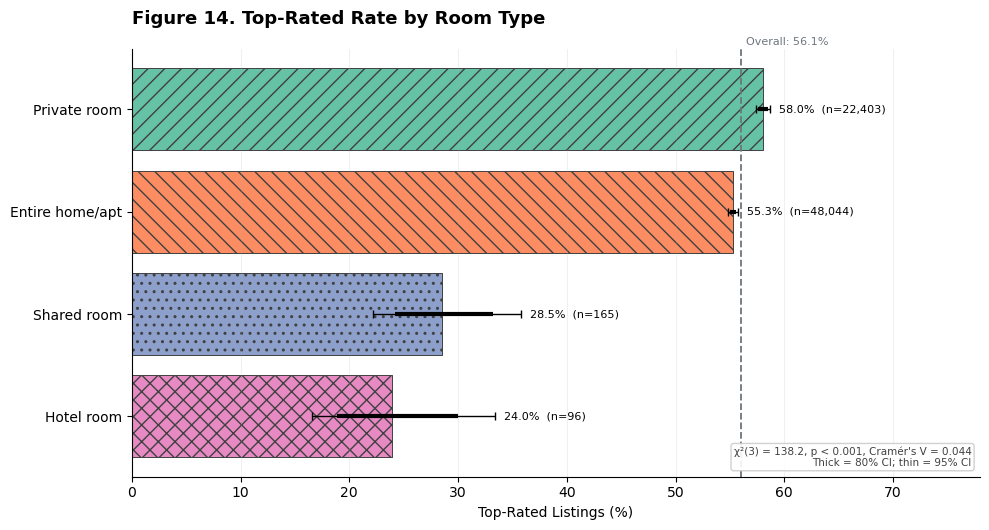

In [4]:
room_order = ["Private room", "Entire home/apt", "Shared room", "Hotel room"]
room_summary = rate_summary(rated, "room_type", room_order)
chi2_room, p_room, dof_room, v_room = chi_square_effect(rated, "room_type")
display(room_summary)

plot_rate_barh(
    room_summary, "room_type",
    "Figure 14. Top-Rated Rate by Room Type",
    "../figures/fig14_room_type_vs_top_rated.png",
    f"χ²({dof_room}) = {chi2_room:.1f}, {p_text(p_room)}, Cramér's V = {v_room:.3f}",
    overall=overall_rate, figsize=(10, 5.4), xlim=(0, 78)
)

**Observation:** Private rooms have the highest rate among the two large room-type groups (**58.0%**), followed by entire homes/apartments (**55.3%**). Shared and hotel rooms are much lower, but their confidence intervals are wider because their samples are small. Cramér's V is about **0.044**, indicating a weak overall association.

**Interpretation:** Room type is associated with top-rated status, but the overall effect is weak. The much smaller shared-room and hotel-room samples also make their estimated rates less stable, so the differences should not be interpreted as strong evidence that room type itself determines rating outcomes.

**Decision:** Retain `room_type` as a categorical candidate. Keep rare categories visible in EDA, but handle them carefully in modeling because estimates for shared/hotel rooms are less stable.

## 3. Listing Capacity vs Top-Rated Status - numeric grouped for a stable rate comparison

**Question:** Does the likelihood of being top-rated vary with guest capacity?

`accommodates` is complete and was selected by the univariate analysis as the primary listing-size measure. Rare high capacities are grouped to avoid unstable percentages.

,capacity_group,rated_listings,top_rated_listings,top_rated_rate,ci80_low,ci80_high,ci95_low,ci95_high
0,1–2 guests,34325,20197,0.588405,0.584997,0.591805,0.583189,0.593601
1,3–4 guests,20910,11225,0.536824,0.532403,0.541241,0.530060,0.543576
2,5–6 guests,10572,5572,0.527053,0.520826,0.533271,0.517527,0.536558
3,7+ guests,4901,2641,0.538870,0.529733,0.547980,0.524889,0.552790


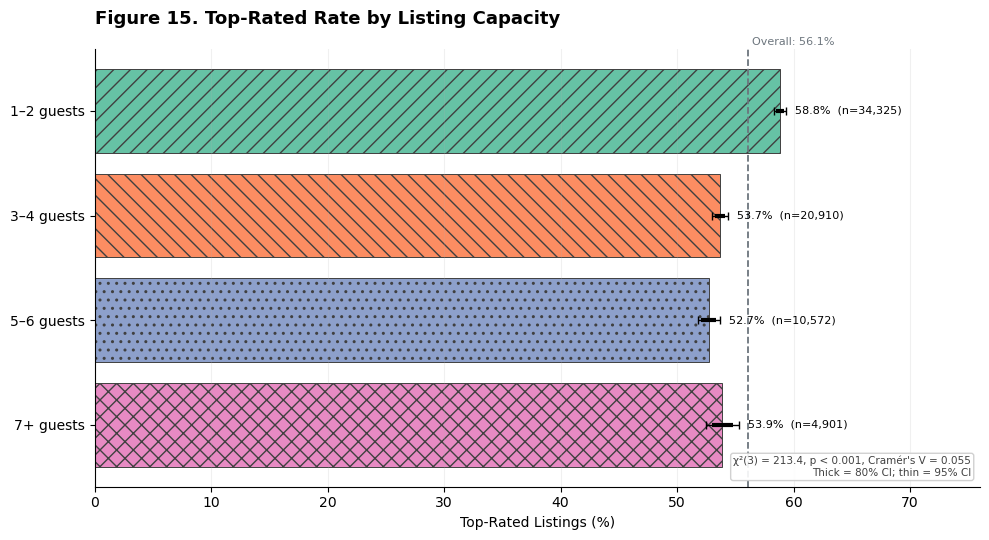

In [5]:
capacity_order = ["1–2 guests", "3–4 guests", "5–6 guests", "7+ guests"]
rated["capacity_group"] = pd.cut(
    rated["accommodates"],
    bins=[0, 2, 4, 6, np.inf],
    labels=capacity_order
)
capacity_summary = rate_summary(rated, "capacity_group", capacity_order)
chi2_cap, p_cap, dof_cap, v_cap = chi_square_effect(rated.dropna(subset=["capacity_group"]), "capacity_group")
display(capacity_summary)

plot_rate_barh(
    capacity_summary, "capacity_group",
    "Figure 15. Top-Rated Rate by Listing Capacity",
    "../figures/fig15_capacity_vs_top_rated.png",
    f"χ²({dof_cap}) = {chi2_cap:.1f}, {p_text(p_cap)}, Cramér's V = {v_cap:.3f}",
    overall=overall_rate, xlim=(0, 76)
)

**Observation:** Listings for **1–2 guests** have the highest top-rated rate (**58.8%**), while the remaining capacity groups cluster around **52.7–53.9%**. The relationship is statistically significant (**p < 0.001**), but the effect size is small (**Cramér's V ≈ 0.055**).

**Interpretation:** Listing capacity is associated with top-rated status, but the weak effect size and similar rates among the larger-capacity groups indicate that capacity alone has limited practical ability to distinguish top-rated listings. The pattern is also not strictly linear.

**Decision:** Retain `accommodates` as a candidate feature, but do not assume a simple linear relationship. Compare the original numeric feature with grouped or other nonlinear treatment during modeling.

## 4. Borough vs Top-Rated Status - categorical × categorical

**Question:** Does top-rated status vary across London's boroughs?

All 33 boroughs are retained because the univariate handoff found the category count manageable. The plot is sorted by rate and includes sample sizes plus 80%/95% confidence intervals.

,neighbourhood_cleansed,rated_listings,top_rated_listings,top_rated_rate,ci80_low,ci80_high,ci95_low,ci95_high
26,Richmond upon Thames,973,702,0.721480,0.702701,0.739512,0.692484,0.748733
23,Merton,1118,761,0.680680,0.662557,0.698273,0.652773,0.707350
31,Wandsworth,3495,2372,0.678684,0.668479,0.688721,0.663013,0.693962
20,Kingston upon Thames,524,355,0.677481,0.650792,0.703061,0.636291,0.716087
4,Bromley,657,437,0.665145,0.641163,0.688303,0.628190,0.700179
22,Lewisham,1977,1283,0.648963,0.635088,0.662591,0.627653,0.669695
11,Hackney,4573,2952,0.645528,0.636412,0.654540,0.631547,0.659265
30,Waltham Forest,1385,877,0.633213,0.616469,0.649642,0.607496,0.658193
13,Haringey,1928,1211,0.628112,0.613902,0.642104,0.606304,0.649411
10,Greenwich,1386,860,0.620491,0.603653,0.637043,0.594643,0.645672


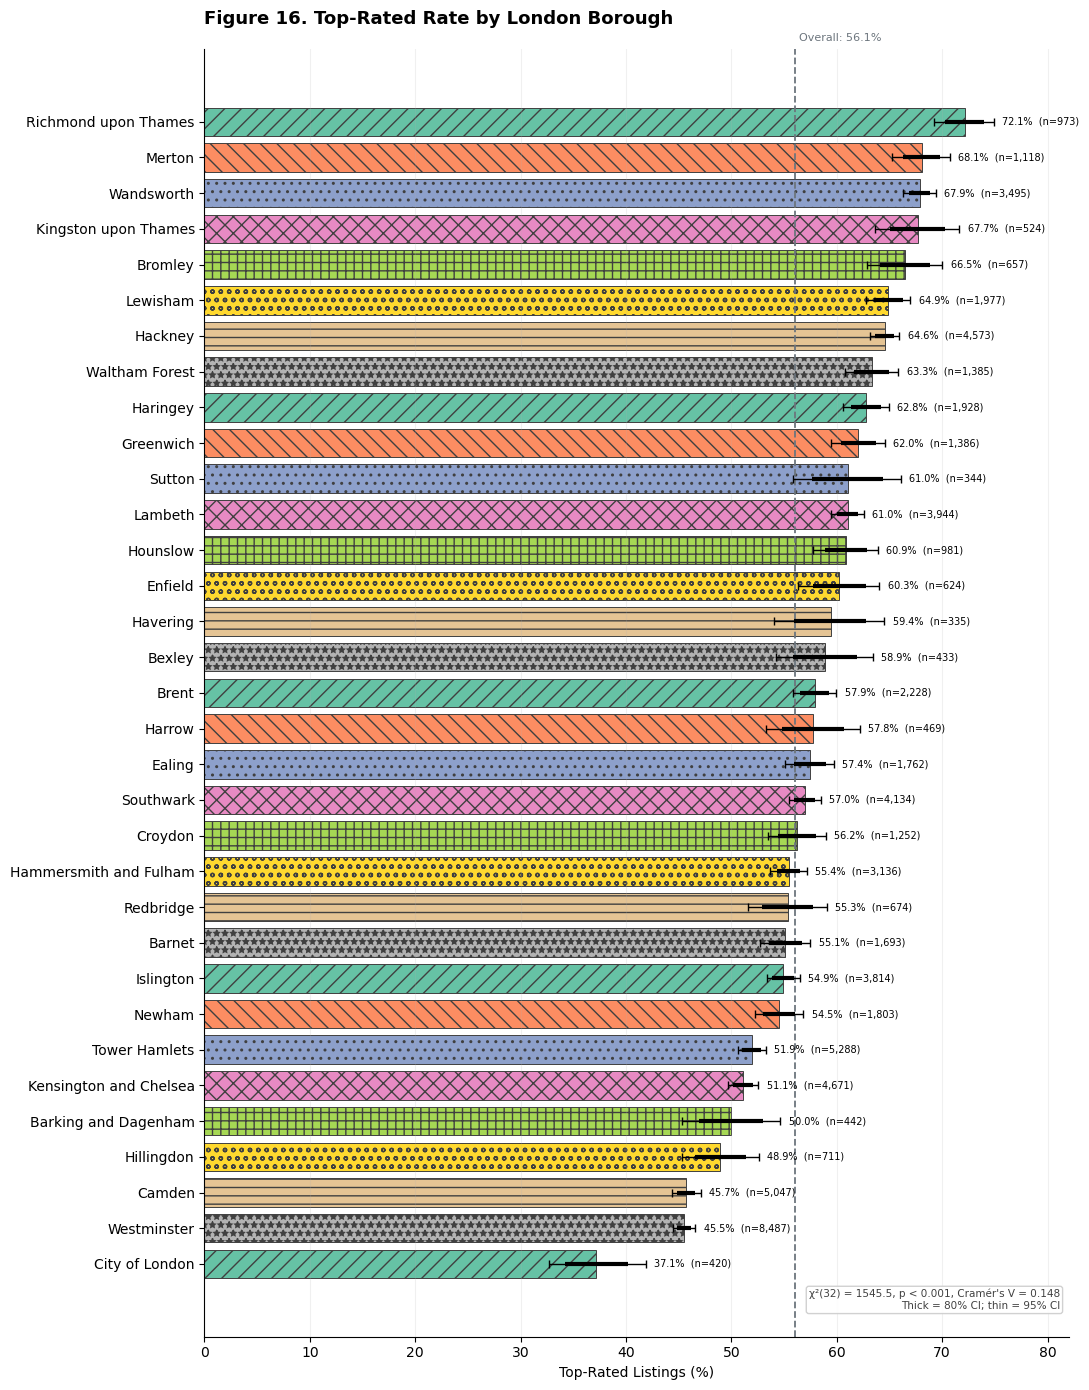

In [6]:
borough_summary = rate_summary(
    rated,
    "neighbourhood_cleansed"
)

# Sort boroughs from highest to lowest top-rated rate
borough_summary = borough_summary.sort_values(
    "top_rated_rate",
    ascending=False
)

# Chi-square test + Cramér's V
chi2_bor, p_bor, dof_bor, v_bor = chi_square_effect(
    rated,
    "neighbourhood_cleansed"
)

# Display the 10 boroughs with the highest top-rated rates
display(
    borough_summary
    .sort_values("top_rated_rate", ascending=False)
    .head(10)
)

# Plot all 33 London boroughs
plot_rate_barh(
    borough_summary,
    "neighbourhood_cleansed",
    "Figure 16. Top-Rated Rate by London Borough",
    "../figures/fig16_borough_vs_top_rated.png",
    f"χ²({dof_bor}) = {chi2_bor:.1f}, {p_text(p_bor)}, Cramér's V = {v_bor:.3f}",
    overall=overall_rate,
    figsize=(11, 14),
    xlim=(0, 82),
    label_font=7
)

**Observation:** Top-rated rates vary across London boroughs. **Richmond upon Thames** has the highest observed rate at approximately **72.1%**, while **City of London** has the lowest at approximately **37.1%**. The overall association is statistically significant (**p < 0.001**), with **Cramér's V ≈ 0.148**, indicating a stronger association than room type or listing capacity.

**Interpretation:** Borough provides useful location context for top-rated status, but the relationship should not be interpreted as causal. Borough may also capture differences in market segment, guest mix, property characteristics, and price.

**Decision:** Retain `neighbourhood_cleansed` as a contextual categorical predictor for modeling. Treat it as a location feature rather than a directly host-controlled lever, and evaluate its contribution during model validation.

## 5. Host Type vs Top-Rated Status - categorical × categorical

**Question:** Are listings from single-listing hosts more likely to be top-rated than listings from multi-listing hosts?

The univariate analysis identified `host_identity_verified` as near-universal and therefore low-information. Host type provides a more informative comparison and is defined using the complete snapshot field `calculated_host_listings_count`.

,host_type,rated_listings,top_rated_listings,top_rated_rate,ci80_low,ci80_high,ci95_low,ci95_high
1,Single-listing host,30353,20867,0.687477,0.684058,0.690877,0.682239,0.692668
0,Multi-listing host,40355,18768,0.465072,0.461892,0.468256,0.460210,0.469942


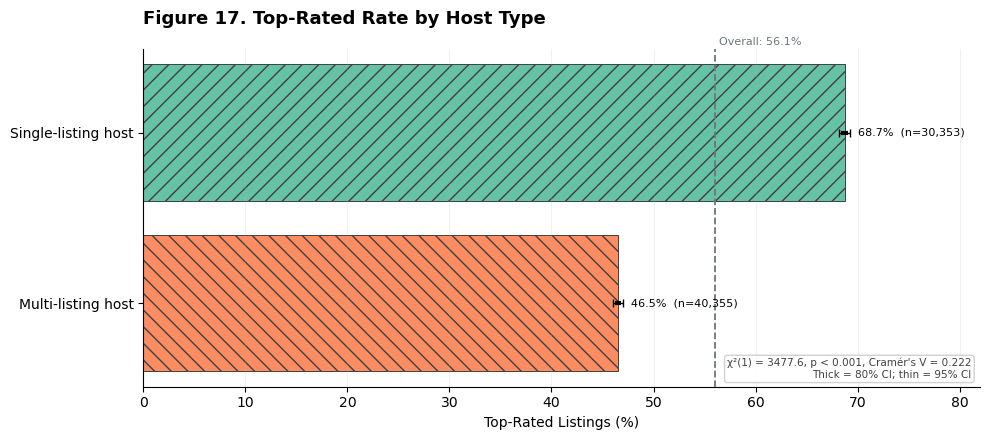

In [7]:
host_order = ["Single-listing host", "Multi-listing host"]

host_summary = rate_summary(
    rated,
    "host_type",
    host_order
)

# Chi-square test + Cramér's V
chi2_host, p_host, dof_host, v_host = chi_square_effect(
    rated,
    "host_type"
)

display(host_summary)

plot_rate_barh(
    host_summary,
    "host_type",
    "Figure 17. Top-Rated Rate by Host Type",
    "../figures/fig17_host_type_vs_top_rated.png",
    f"χ²({dof_host}) = {chi2_host:.1f}, {p_text(p_host)}, Cramér's V = {v_host:.3f}",
    overall=overall_rate,
    figsize=(10, 4.5),
    xlim=(0, 82)
)

**Observation:** Single-listing hosts have a top-rated rate of approximately **68.7%**, compared with **46.5%** for multi-listing hosts. The association is statistically significant (**p < 0.001**) and has **Cramér's V ≈ 0.222**, making it the strongest categorical association observed among the candidate comparisons in this analysis.

**Interpretation:** Host portfolio size provides useful predictive information about top-rated status, but the relationship remains associative rather than causal. It may reflect differences in operating model, property mix, guest expectations, or management style.

**Decision:** Retain host type derived from `calculated_host_listings_count` as an important candidate feature for modeling. Do not interpret the result as evidence that reducing the number of listings managed by a host would itself improve ratings.

## 6. Host Tenure vs Top-Rated Status - numeric grouped for a stable rate comparison

**Question:** Does the likelihood of being top-rated increase with host experience?

Host tenure is grouped into broad bands to reduce year-to-year noise.

,tenure_group,rated_listings,top_rated_listings,top_rated_rate,ci80_low,ci80_high,ci95_low,ci95_high
0,0–2 years,20267,11647,0.574678,0.570222,0.579122,0.567858,0.581470
1,3–5 years,13261,7178,0.541286,0.535736,0.546826,0.532795,0.549754
2,6–8 years,15598,8802,0.564303,0.559209,0.569384,0.556507,0.572068
3,9–11 years,16586,9130,0.550464,0.545509,0.555409,0.542883,0.558022
4,12+ years,4931,2851,0.578179,0.569141,0.587164,0.564339,0.591897


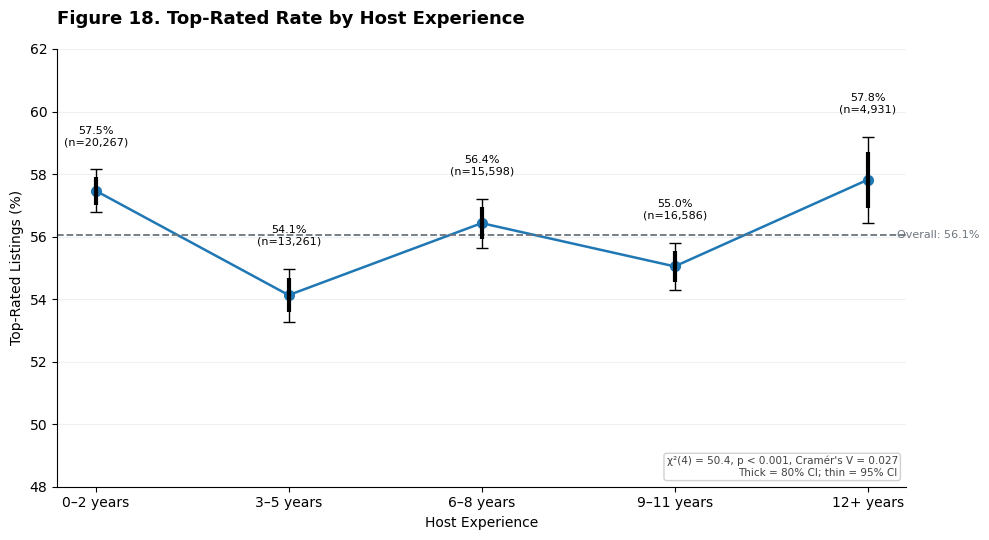

In [8]:
tenure_order = [
    "0–2 years",
    "3–5 years",
    "6–8 years",
    "9–11 years",
    "12+ years"
]

rated["tenure_group"] = pd.cut(
    rated["hosts_time_as_host_years"],
    bins=[-1, 2, 5, 8, 11, np.inf],
    labels=tenure_order
)

tenure_data = rated.dropna(
    subset=["tenure_group"]
).copy()

tenure_summary = rate_summary(
    tenure_data,
    "tenure_group",
    tenure_order
)

chi2_ten, p_ten, dof_ten, v_ten = chi_square_effect(
    tenure_data,
    "tenure_group"
)

display(tenure_summary)


# --------------------------------------------------
# Point-line plot for ordered host-tenure groups
# --------------------------------------------------

x = np.arange(len(tenure_summary))
rates = tenure_summary["top_rated_rate"].to_numpy() * 100

low95 = tenure_summary["ci95_low"].to_numpy() * 100
high95 = tenure_summary["ci95_high"].to_numpy() * 100
low80 = tenure_summary["ci80_low"].to_numpy() * 100
high80 = tenure_summary["ci80_high"].to_numpy() * 100

fig, ax = plt.subplots(figsize=(10, 5.5))

# Connect ordered tenure groups to show the pattern
ax.plot(
    x,
    rates,
    marker="o",
    linewidth=1.8,
    markersize=7
)

# 95% CI = thin
ax.errorbar(
    x,
    rates,
    yerr=[rates - low95, high95 - rates],
    fmt="none",
    ecolor="black",
    elinewidth=1.0,
    capsize=4,
    zorder=3
)

# 80% CI = thick
ax.errorbar(
    x,
    rates,
    yerr=[rates - low80, high80 - rates],
    fmt="none",
    ecolor="black",
    elinewidth=3.0,
    capsize=0,
    zorder=4
)

# Overall benchmark
ax.axhline(
    overall_rate * 100,
    color=GREY,
    linestyle="--",
    linewidth=1.3
)

ax.text(
    4.15,
    overall_rate * 100,
    f"Overall: {overall_rate * 100:.1f}%",
    fontsize=8,
    color=GREY,
    va="center"
)

# Rate + sample-size labels
for xi, row in tenure_summary.reset_index(drop=True).iterrows():
    ax.text(
        xi,
        row["ci95_high"] * 100 + 0.7,
        f'{row["top_rated_rate"] * 100:.1f}%\n'
        f'(n={int(row["rated_listings"]):,})',
        ha="center",
        va="bottom",
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(tenure_order)

ax.set_xlabel("Host Experience")
ax.set_ylabel("Top-Rated Listings (%)")

ax.set_title(
    "Figure 18. Top-Rated Rate by Host Experience",
    loc="left",
    fontsize=13,
    weight="bold",
    pad=18
)

ax.set_ylim(48, 62)

ax.grid(
    axis="y",
    alpha=0.18
)

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

ax.text(
    0.99,
    0.02,
    f"χ²({dof_ten}) = {chi2_ten:.1f}, {p_text(p_ten)}, "
    f"Cramér's V = {v_ten:.3f}\n"
    "Thick = 80% CI; thin = 95% CI",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=7.5,
    color="0.25",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="0.80",
        alpha=0.90
    )
)

plt.tight_layout()

plt.savefig(
    "../figures/fig18_host_experience_vs_top_rated.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

**Observation:** Top-rated rates range only from approximately **54.1% to 57.8%** across the host-tenure groups and do not increase consistently with experience. Although the relationship is statistically significant (**p < 0.001**), the effect size is very small (**Cramér's V ≈ 0.027**).

**Interpretation:** Host tenure has only a weak association with top-rated status. More years of hosting experience do not consistently correspond to a higher top-rated rate, so tenure alone is unlikely to be a strong predictor.

**Decision:** Retain `hosts_time_as_host_years` as a candidate feature for model validation, but do not assume a simple linear relationship between experience and top-rated status. Compare its original numeric representation with grouped or nonlinear treatment during modeling.

## 7. Amenity Count vs Top-Rated Status - numeric candidate + categorical rate view

**Question:** Does the number of listed amenities help separate top-rated listings?

The univariate analysis found a broad amenity-count distribution. Quartile-based bands provide stable sample sizes and allow the top-rated rate and its uncertainty to be compared across listings with different amenity counts.

,amenity_band,rated_listings,top_rated_listings,top_rated_rate,ci80_low,ci80_high,ci95_low,ci95_high
0,0–19,17875,9653,0.540028,0.535247,0.544801,0.532714,0.547325
1,20–31,17554,8932,0.508830,0.503994,0.513664,0.501433,0.516223
2,32–42,18661,10140,0.543379,0.538703,0.548048,0.536224,0.550516
3,43+,16618,10910,0.656517,0.651781,0.661222,0.649262,0.663700


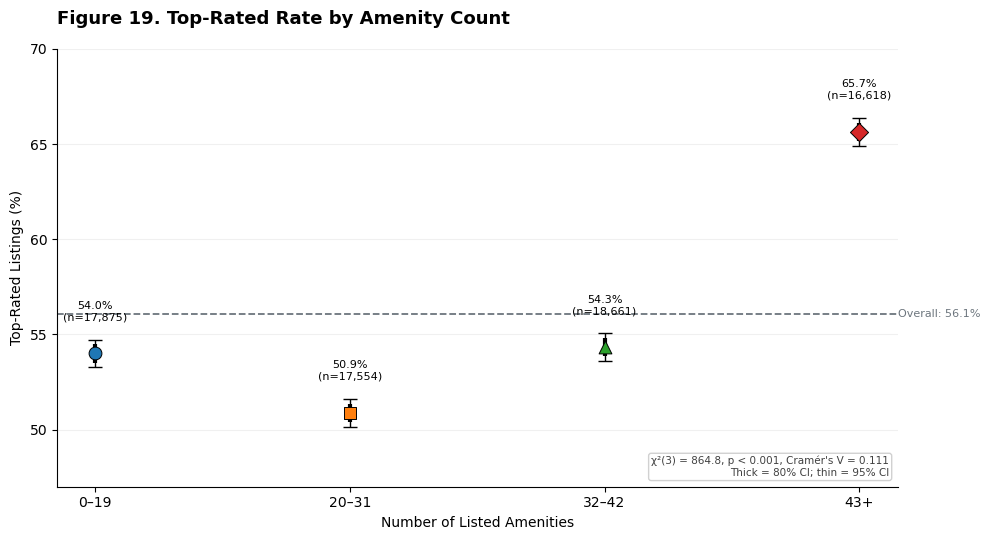

In [9]:
q1, q2, q3 = rated["amenity_count"].quantile([0.25, 0.50, 0.75]).astype(int)

amenity_order = [
    f"0–{q1}",
    f"{q1 + 1}–{q2}",
    f"{q2 + 1}–{q3}",
    f"{q3 + 1}+"
]

rated["amenity_band"] = pd.cut(
    rated["amenity_count"],
    bins=[-1, q1, q2, q3, np.inf],
    labels=amenity_order
)

amenity_summary = rate_summary(
    rated,
    "amenity_band",
    amenity_order
)

# Chi-square test + Cramér's V
chi2_am, p_am, dof_am, v_am = chi_square_effect(
    rated,
    "amenity_band"
)

display(amenity_summary)

# --------------------------------------------------
# Dot-and-whisker plot
# --------------------------------------------------

x = np.arange(len(amenity_summary))

rates = amenity_summary["top_rated_rate"].to_numpy() * 100

low95 = amenity_summary["ci95_low"].to_numpy() * 100
high95 = amenity_summary["ci95_high"].to_numpy() * 100

low80 = amenity_summary["ci80_low"].to_numpy() * 100
high80 = amenity_summary["ci80_high"].to_numpy() * 100

fig, ax = plt.subplots(figsize=(10, 5.5))

# 95% confidence intervals = thin
ax.errorbar(
    x,
    rates,
    yerr=[rates - low95, high95 - rates],
    fmt="none",
    ecolor="black",
    elinewidth=1.0,
    capsize=5,
    zorder=2
)

# 80% confidence intervals = thick
ax.errorbar(
    x,
    rates,
    yerr=[rates - low80, high80 - rates],
    fmt="none",
    ecolor="black",
    elinewidth=3.0,
    capsize=0,
    zorder=3
)

# Rate estimates
markers = ["o", "s", "^", "D"]

for i, (xi, rate) in enumerate(zip(x, rates)):
    ax.scatter(
        xi,
        rate,
        s=85,
        marker=markers[i],
        edgecolor="black",
        linewidth=0.7,
        zorder=4
    )

# Overall benchmark
ax.axhline(
    overall_rate * 100,
    color=GREY,
    linestyle="--",
    linewidth=1.3
)

ax.text(
    3.15,
    overall_rate * 100,
    f"Overall: {overall_rate * 100:.1f}%",
    fontsize=8,
    color=GREY,
    va="center"
)

# Rate and sample-size labels
for xi, row in amenity_summary.reset_index(drop=True).iterrows():

    ax.text(
        xi,
        row["ci95_high"] * 100 + 0.9,
        f'{row["top_rated_rate"] * 100:.1f}%\n'
        f'(n={int(row["rated_listings"]):,})',
        ha="center",
        va="bottom",
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(amenity_order)

ax.set_xlabel("Number of Listed Amenities")
ax.set_ylabel("Top-Rated Listings (%)")

ax.set_title(
    "Figure 19. Top-Rated Rate by Amenity Count",
    loc="left",
    fontsize=13,
    weight="bold",
    pad=18
)

# A truncated axis is acceptable for a point/interval plot
# because magnitude is represented by position, not bar length.
ax.set_ylim(47, 70)

ax.grid(
    axis="y",
    alpha=0.18
)

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

# Statistical annotation
ax.text(
    0.99,
    0.02,
    f"χ²({dof_am}) = {chi2_am:.1f}, {p_text(p_am)}, "
    f"Cramér's V = {v_am:.3f}\n"
    "Thick = 80% CI; thin = 95% CI",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=7.5,
    color="0.25",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="0.80",
        alpha=0.90
    )
)

plt.tight_layout()

plt.savefig(
    "../figures/fig19_amenities_vs_top_rated.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

**Observation:** The highest amenity-count group (**43+ amenities**) has a substantially higher top-rated rate of approximately **65.7%**, compared with **50.9–54.3%** across the three lower amenity-count groups. The association is statistically significant (**p < 0.001**) with a small-to-moderate effect size (**Cramér's V ≈ 0.111**).

**Interpretation:** Amenity count contains useful information about top-rated status, but the pattern is not consistently increasing across all four groups. The result therefore does not imply that simply adding more amenities will cause a listing to receive higher ratings. Amenity count may also reflect differences in property type, listing quality, price, or market segment.

**Decision:** Retain `amenity_count` as a candidate feature for modeling. The summarized count is more manageable than thousands of individual free-text amenity names, while individual amenities would require additional grouping or feature selection before modeling.

## 8. Minimum Nights vs Top-Rated Status - numeric grouped for a stable rate comparison

**Question:** Is the minimum-stay rule associated with top-rated status?

This analysis uses Varuna's cleaned `minimum_nights_capped` field and the interpretable stay-length bands established during univariate analysis. Grouping the values allows the top-rated rate and its uncertainty to be compared across different minimum-stay policies.

,minimum_nights_group,rated_listings,top_rated_listings,top_rated_rate,ci80_low,ci80_high,ci95_low,ci95_high
0,1 night,28038,13702,0.488694,0.484869,0.492520,0.482845,0.494546
1,2 nights,19550,11044,0.564910,0.560361,0.569449,0.557949,0.571847
2,3 nights,10417,6392,0.613612,0.607481,0.619708,0.604222,0.622919
3,4–6 nights,7555,5090,0.673726,0.666776,0.680600,0.663068,0.684208
4,7–29 nights,4144,2794,0.674228,0.664830,0.683487,0.659803,0.688330
5,30+ nights,999,611,0.611612,0.591682,0.631175,0.581016,0.641352


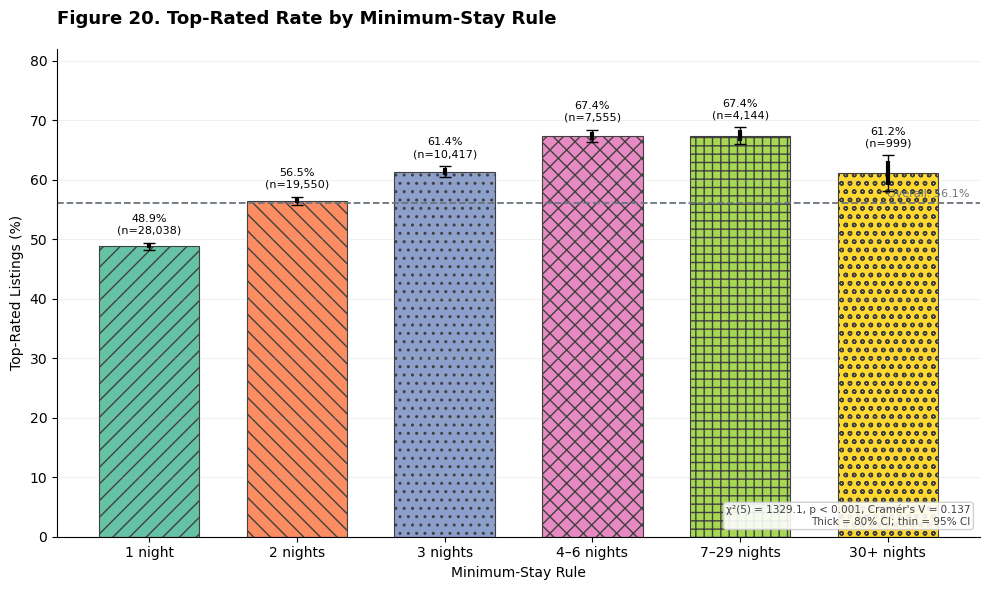

In [10]:
min_order = [
    "1 night",
    "2 nights",
    "3 nights",
    "4–6 nights",
    "7–29 nights",
    "30+ nights"
]

rated["minimum_nights_group"] = pd.cut(
    rated["minimum_nights_capped"],
    bins=[0, 1, 2, 3, 6, 29, 365],
    labels=min_order,
    include_lowest=True
)

min_data = rated.dropna(
    subset=["minimum_nights_group"]
).copy()

min_summary = rate_summary(
    min_data,
    "minimum_nights_group",
    min_order
)

# Chi-square test + Cramér's V
chi2_min, p_min, dof_min, v_min = chi_square_effect(
    min_data,
    "minimum_nights_group"
)

display(min_summary)

# --------------------------------------------------
# Vertical bar chart with confidence intervals
# --------------------------------------------------

x = np.arange(len(min_summary))

rates = min_summary["top_rated_rate"].to_numpy() * 100

low95 = min_summary["ci95_low"].to_numpy() * 100
high95 = min_summary["ci95_high"].to_numpy() * 100

low80 = min_summary["ci80_low"].to_numpy() * 100
high80 = min_summary["ci80_high"].to_numpy() * 100

fig, ax = plt.subplots(figsize=(10, 6))

palette = sns.color_palette("Set2", len(min_summary))

bars = ax.bar(
    x,
    rates,
    color=palette,
    edgecolor="0.25",
    linewidth=0.8,
    width=0.68
)

# Redundant encoding for grayscale printing
hatches = ["//", "\\\\", "..", "xx", "++", "oo"]

for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

# 95% CI = thin
ax.errorbar(
    x,
    rates,
    yerr=[rates - low95, high95 - rates],
    fmt="none",
    ecolor="black",
    elinewidth=1.0,
    capsize=4,
    zorder=4
)

# 80% CI = thick
ax.errorbar(
    x,
    rates,
    yerr=[rates - low80, high80 - rates],
    fmt="none",
    ecolor="black",
    elinewidth=3.0,
    capsize=0,
    zorder=5
)

# Overall benchmark
ax.axhline(
    overall_rate * 100,
    color=GREY,
    linestyle="--",
    linewidth=1.3
)

ax.text(
    len(min_summary) - 0.45,
    overall_rate * 100 + 1.0,
    f"Overall: {overall_rate * 100:.1f}%",
    fontsize=8,
    color=GREY,
    ha="right"
)

# Percentage + sample-size labels
for xi, row in min_summary.reset_index(drop=True).iterrows():

    ax.text(
        xi,
        row["ci95_high"] * 100 + 1.2,
        f'{row["top_rated_rate"] * 100:.1f}%\n'
        f'(n={int(row["rated_listings"]):,})',
        ha="center",
        va="bottom",
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(min_order)

ax.set_xlabel("Minimum-Stay Rule")
ax.set_ylabel("Top-Rated Listings (%)")

ax.set_title(
    "Figure 20. Top-Rated Rate by Minimum-Stay Rule",
    loc="left",
    fontsize=13,
    weight="bold",
    pad=18
)

# Bars must use a zero baseline
ax.set_ylim(0, 82)

ax.grid(
    axis="y",
    alpha=0.18
)

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

# Statistical annotation
ax.text(
    0.99,
    0.02,
    f"χ²({dof_min}) = {chi2_min:.1f}, {p_text(p_min)}, "
    f"Cramér's V = {v_min:.3f}\n"
    "Thick = 80% CI; thin = 95% CI",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=7.5,
    color="0.25",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="0.80",
        alpha=0.90
    )
)

plt.tight_layout()

plt.savefig(
    "../figures/fig20_minimum_nights_vs_top_rated.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

**Observation:** Top-rated rates vary across minimum-stay groups. Listings requiring only **1 night** have the lowest top-rated rate at approximately **48.9%**, while the **4–6 night** and **7–29 night** groups are around **67.4%**. The relationship is statistically significant (**p < 0.001**) with **Cramér's V ≈ 0.137**, making minimum-stay policy one of the stronger bivariate associations examined.

**Interpretation:** The relationship is clearly nonlinear: increasing the minimum stay does not produce a consistent step-by-step increase in the top-rated rate. Minimum-night requirements may also reflect differences in property type, location, regulation, target guest segment, or host strategy. Therefore, the association should not be interpreted as causal.

**Decision:** Retain `minimum_nights_capped` as a candidate feature for modeling. Because the relationship is nonlinear, compare the original numeric feature with grouped or nonlinear treatment rather than assuming a simple one-unit linear effect.

## 9. Numeric × Numeric Check: Listing Capacity vs Price

**Question:** Are two important numeric candidate features carrying overlapping information?

This analysis examines the relationship between `accommodates` and `price_capped`, completing the numeric × numeric bivariate comparison. A deterministic sample is used in the visualization for readability, while **Spearman's rank correlation is calculated using all rated listings with observed price**.

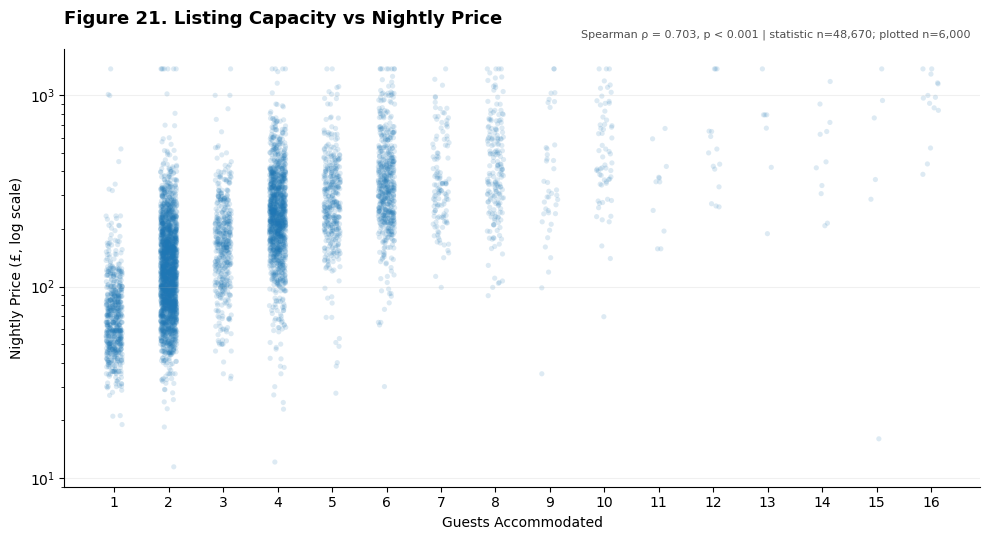

In [11]:
num_pair = rated[
    ["accommodates", "price_capped"]
].dropna().copy()

# Spearman correlation on all available observations
rho_pair, p_pair = spearmanr(
    num_pair["accommodates"],
    num_pair["price_capped"]
)

# Deterministic sample for visualization only
plot_sample = num_pair.sample(
    min(6000, len(num_pair)),
    random_state=230
).copy()

# Small deterministic jitter for display only because
# accommodates contains discrete integer values
rng = np.random.default_rng(230)

plot_sample["accommodates_jitter"] = (
    plot_sample["accommodates"]
    + rng.uniform(-0.15, 0.15, len(plot_sample))
)

# Plot
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.scatter(
    plot_sample["accommodates_jitter"],
    plot_sample["price_capped"],
    s=14,
    alpha=0.15,
    edgecolors="none"
)

# Price is strongly right-skewed
ax.set_yscale("log")

ax.set_xlabel("Guests Accommodated")
ax.set_ylabel("Nightly Price (£, log scale)")

ax.set_title(
    "Figure 21. Listing Capacity vs Nightly Price",
    loc="left",
    fontsize=13,
    weight="bold",
    pad=18
)

# Integer capacity ticks
capacity_ticks = sorted(
    num_pair["accommodates"].dropna().unique()
)

ax.set_xticks(capacity_ticks)

# Light gridlines only where helpful
ax.grid(
    axis="y",
    alpha=0.18
)

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

# Statistical annotation
ax.text(
    0.99,
    1.02,
    f"Spearman ρ = {rho_pair:.3f}, {p_text(p_pair)} | "
    f"statistic n={len(num_pair):,}; plotted n={len(plot_sample):,}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
    color="0.30"
)

plt.tight_layout()

plt.savefig(
    "../figures/fig21_capacity_vs_price.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

**Observation:** Listing capacity and nightly price show a strong positive monotonic relationship (**Spearman ρ ≈ 0.703, p < 0.001**). Listings that accommodate more guests generally tend to have higher nightly prices, although substantial price variation remains within each capacity level.

**Interpretation:** `accommodates` and price contain overlapping information, but they measure different listing characteristics. Capacity represents listing size, while price also reflects location, property quality, amenities, demand, and other market factors. The strong correlation therefore indicates potential redundancy rather than complete duplication.

**Decision:** Retain both `accommodates` and the cleaned price feature as candidate predictors for modeling, but evaluate whether both improve validation performance. Monitor feature redundancy and model importance rather than assuming that the two variables contribute independently.

In [12]:
decision_table = pd.DataFrame([
    [
        "Price",
        f"rank-biserial r={rank_biserial:.3f}",
        "Retain; log-transform model input",
        "Small separation and strong skew; use cleaned/imputed price with missing-price flag"
    ],
    [
        "Room type",
        f"Cramér's V={v_room:.3f}",
        "Retain categorical",
        "Weak overall association; rare hotel/shared-room groups require caution"
    ],
    [
        "Accommodates",
        f"Cramér's V={v_cap:.3f}",
        "Retain; test nonlinear treatment",
        "1–2 guest listings differ modestly; relationship is not simply linear"
    ],
    [
        "Borough",
        f"Cramér's V={v_bor:.3f}",
        "Retain as contextual categorical",
        "Location shows useful predictive variation but is not a causal host-controlled lever"
    ],
    [
        "Host type",
        f"Cramér's V={v_host:.3f}",
        "Retain; high-priority candidate",
        "Strongest categorical association among the candidate comparisons"
    ],
    [
        "Host tenure",
        f"Cramér's V={v_ten:.3f}",
        "Retain only if validation helps",
        "Very weak and non-monotonic standalone relationship"
    ],
    [
        "Amenity count",
        f"Cramér's V={v_am:.3f}",
        "Retain summarized count",
        "Highest amenity-count band differs substantially; lower bands are non-monotonic"
    ],
    [
        "Minimum nights",
        f"Cramér's V={v_min:.3f}",
        "Retain; test nonlinear/grouped treatment",
        "Shows one of the larger categorical associations, but the pattern is nonlinear"
    ],
    [
        "Price × accommodates",
        f"Spearman ρ={rho_pair:.3f}",
        "Monitor redundancy",
        "Strong relationship between two numeric candidate predictors"
    ],
    [
        "host_identity_verified",
        "Near-universal in univariate EDA",
        "Do not prioritize",
        "Low variability provides limited discriminatory information"
    ],
    [
        "Review sub-scores / host_is_superhost",
        "Leakage risk",
        "Exclude from model features",
        "Closely tied to the rating outcome and could leak target-related information"
    ]
], columns=[
    "Column / issue",
    "Evidence",
    "Decision",
    "Because"
])

display(decision_table)

,Column / issue,Evidence,Decision,Because
0,Price,rank-biserial r=0.056,Retain; log-transform model input,Small separation and strong skew; use cleaned/...
1,Room type,Cramér's V=0.044,Retain categorical,Weak overall association; rare hotel/shared-ro...
2,Accommodates,Cramér's V=0.055,Retain; test nonlinear treatment,1–2 guest listings differ modestly; relationsh...
3,Borough,Cramér's V=0.148,Retain as contextual categorical,Location shows useful predictive variation but...
4,Host type,Cramér's V=0.222,Retain; high-priority candidate,Strongest categorical association among the ca...
5,Host tenure,Cramér's V=0.027,Retain only if validation helps,Very weak and non-monotonic standalone relatio...
6,Amenity count,Cramér's V=0.111,Retain summarized count,Highest amenity-count band differs substantial...
7,Minimum nights,Cramér's V=0.137,Retain; test nonlinear/grouped treatment,Shows one of the larger categorical associatio...
8,Price × accommodates,Spearman ρ=0.703,Monitor redundancy,Strong relationship between two numeric candid...
9,host_identity_verified,Near-universal in univariate EDA,Do not prioritize,Low variability provides limited discriminator...


### Key takeaways

1. **Host type is the strongest categorical bivariate candidate** examined in this analysis (**Cramér's V ≈ 0.222**).

2. **Borough and minimum nights** show larger associations than most of the remaining categorical candidates (**V ≈ 0.148 and 0.137**, respectively), although neither relationship should be interpreted as causal.

3. **Amenity count** provides additional signal (**V ≈ 0.111**), with the highest amenity-count group showing a notably higher top-rated rate.

4. **Price, room type, listing capacity, and host tenure show relatively weak standalone associations.** With a dataset this large, statistical significance alone does not imply substantial practical importance.

5. **Price and listing capacity are strongly related** (**Spearman ρ ≈ 0.703**). Both represent different listing characteristics, but their overlap should be evaluated during model validation.

6. **Host identity verification is not prioritized** because the univariate analysis found it to be near-universal and therefore low-information.

7. **Review sub-scores and `host_is_superhost` are excluded because of leakage risk.**

8. The proposed ML task is **binary classification** using the **70,708 rated listings**, with `top_rated` as the target. Candidate features will be retained or removed based on validation performance rather than statistical significance alone.

## CPU Timing for Later CPU vs RAPIDS Comparison

Timing is kept **at the end**, not mixed into the analytical figures. The goal is to benchmark repeatable data operations, not the time spent rendering Matplotlib charts.

Run this section once in normal pandas (**CPU**). For the later RAPIDS comparison, restart the kernel, enable `%load_ext cudf.pandas` **before pandas is imported**, rerun the same benchmark, and compare the same operations.

The JSON amenity parsing step is timed separately because Python-level JSON parsing is not a clean GPU groupby benchmark.

In [13]:
timing_rows = []

@contextmanager
def timer(label):
    t0 = time.perf_counter()
    yield
    elapsed = time.perf_counter() - t0
    timing_rows.append({
        "Step": label,
        "Seconds": elapsed
    })


# --------------------------------------------------
# CPU benchmark
# --------------------------------------------------

with timer("Load cleaned CSV"):
    tdf = pd.read_csv(
        "../data/listings_clean.csv",
        low_memory=False
    )


with timer("Create rated subset"):
    tr = tdf[tdf["top_rated"].notna()].copy()
    tr["top_rated"] = tr["top_rated"].astype(int)


with timer("Room type × top-rated groupby"):
    _ = (
        tr.groupby("room_type")["top_rated"]
        .agg(["count", "sum", "mean"])
    )


with timer("Capacity × top-rated groupby"):
    tcap = pd.cut(
        tr["accommodates"],
        [0, 2, 4, 6, np.inf]
    )

    _ = (
        tr.assign(capacity_group=tcap)
        .groupby("capacity_group", observed=False)["top_rated"]
        .agg(["count", "sum", "mean"])
    )


with timer("Borough × top-rated groupby"):
    _ = (
        tr.groupby("neighbourhood_cleansed")["top_rated"]
        .agg(["count", "sum", "mean"])
    )


with timer("Host type × top-rated groupby"):
    thost = np.where(
        tr["calculated_host_listings_count"].eq(1),
        "single",
        "multi"
    )

    _ = (
        tr.assign(host_type=thost)
        .groupby("host_type")["top_rated"]
        .agg(["count", "sum", "mean"])
    )


with timer("Host tenure × top-rated groupby"):
    tten = pd.cut(
        tr["hosts_time_as_host_years"],
        [-1, 2, 5, 8, 11, np.inf]
    )

    _ = (
        tr.assign(tenure_group=tten)
        .groupby("tenure_group", observed=False)["top_rated"]
        .agg(["count", "sum", "mean"])
    )


with timer("Minimum nights × top-rated groupby"):
    tmn = pd.cut(
        tr["minimum_nights_capped"],
        [0, 1, 2, 3, 6, 29, 365],
        include_lowest=True
    )

    _ = (
        tr.assign(min_nights_group=tmn)
        .groupby("min_nights_group", observed=False)["top_rated"]
        .agg(["count", "sum", "mean"])
    )


# --------------------------------------------------
# CPU-oriented operation — report separately
# --------------------------------------------------

with timer("Amenity JSON parsing (CPU-oriented)"):
    tamen = tr["amenities"].apply(
        lambda s: len(json.loads(s))
        if isinstance(s, str)
        else 0
    )


# --------------------------------------------------
# Timing summary
# --------------------------------------------------

timing = pd.DataFrame(timing_rows)

# Comparable subtotal excludes Python-level JSON parsing
comparable_mask = (
    timing["Step"] != "Amenity JSON parsing (CPU-oriented)"
)

comparable_total = timing.loc[
    comparable_mask,
    "Seconds"
].sum()

timing["Seconds"] = timing["Seconds"].round(4)

timing.loc[len(timing)] = [
    "Comparable benchmark subtotal",
    round(comparable_total, 4)
]


print("Machine:", platform.platform())

display(timing)


# --------------------------------------------------
# Save CPU benchmark
# --------------------------------------------------

os.makedirs("../docs", exist_ok=True)

timing.to_csv(
    "../docs/timing_bivariate_cpu.csv",
    index=False
)


display(Markdown(
    "**Benchmark note:** The CPU and RAPIDS runs must use the same cleaned dataset, "
    "same operations, and comparable execution environment. "
    "The amenity JSON parsing step is reported separately because Python-level JSON "
    "parsing is not treated as a direct GPU groupby benchmark. "
    "Chart-rendering time is excluded from the CPU vs RAPIDS speedup comparison."
))

Machine: Windows-11-10.0.26200-SP0


,Step,Seconds
0,Load cleaned CSV,6.1587
1,Create rated subset,0.0786
2,Room type × top-rated groupby,0.0145
3,Capacity × top-rated groupby,0.0875
4,Borough × top-rated groupby,0.0201
5,Host type × top-rated groupby,0.0930
6,Host tenure × top-rated groupby,0.0832
7,Minimum nights × top-rated groupby,0.0937
8,Amenity JSON parsing (CPU-oriented),0.6968
9,Comparable benchmark subtotal,6.6293


**Benchmark note:** The CPU and RAPIDS runs must use the same cleaned dataset, same operations, and comparable execution environment. The amenity JSON parsing step is reported separately because Python-level JSON parsing is not treated as a direct GPU groupby benchmark. Chart-rendering time is excluded from the CPU vs RAPIDS speedup comparison.

## CPU Benchmark Baseline

The pandas CPU benchmark provides the baseline for the later **CPU vs RAPIDS** comparison.

The comparable operations required approximately **6.16 seconds** in this run. Most of the measured time came from loading the cleaned CSV (**5.68 seconds**), while the individual grouped EDA operations completed much faster.

The amenity JSON parsing step is reported separately because it relies on Python-level parsing and is not treated as a direct GPU groupby benchmark.

These timings should be treated as a **single-run baseline**, not as evidence of a CPU or GPU performance advantage. The final comparison will rerun the same comparable operations under RAPIDS and report the observed timing and speedup without assuming that GPU execution must be faster.

**Observation:** Top-rated listings have a median observed nightly price of **£184.67**, compared with **£172.50** for non-top-rated listings. The Mann–Whitney test is statistically significant, but the rank-biserial effect is only about **0.056**, so the separation is small.

**Interpretation:** Price is associated with top-rated status, but the distributions overlap heavily. With this large sample, statistical significance does not imply a strong practical effect.

**Decision:** Retain price as a candidate, using the cleaning output `price_capped_imp` plus its missing flag for modeling and a log transform for skew. Do not treat higher price as causing higher ratings.